# Clasificación de mensajes de odio

## Descripción

En este trabajo se desarrolla un proceso completo de aprendizaje automático para clasificar mensajes en las categorías de odio y no odio.

Se entrenan y comparan distintos modelos de clasificación supervisada, evaluando su rendimiento mediante métricas de precisión, recall, F1-score y matrices de confusión. También se analizan diferentes selecciones de características y se optimizan los hiperparámetros de los modelos.

## Objetivos

* Realizar un análisis exploratorio adecuado al problema de clasificación.
* Analizar la distribución de las clases y las características disponibles.
* Seleccionar los algoritmos de aprendizaje supervisado más adecuados.
* Entrenar y comparar tres modelos de clasificación.
* Optimizar sus hiperparámetros mediante validación cruzada.
* Evaluar los resultados mediante accuracy, precision, recall y F1-score.
* Seleccionar la configuración final con mejor rendimiento.

## Dataset

El dataset original de HateSpeech fue adaptado previamente para esta actividad. El proceso de preparación incluyó:

* Eliminación de valores nulos y duplicados.
* Eliminación de URLs, emojis y menciones a periódicos.
* Eliminación de filas vacías.
* Conversión del texto a minúsculas.
* Eliminación de signos de puntuación, números y espacios adicionales.
* Eliminación de palabras con longitud inferior a dos caracteres.
* Eliminación de stopwords.
* Tokenización y lematización.

También se realizó un proceso de extracción de características:

* Conteo de palabras positivas.
* Conteo de palabras negativas.
* Conteo de los bigramas más comunes.
* Conteo de menciones a otros usuarios.
* Categoría de sentimiento obtenida con `pysentimiento`.
* Estandarización de las características.
* Generación de variables combinadas mediante productos entre características.

Fuente del dataset adaptado:

https://github.com/almudenaris/TAA/blob/main/out.csv

## Autores

* Fernando Sanfiel Reyes
* Carlos Giral Herrero


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.svm import SVC
from tabulate import tabulate
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

## EDA

El objetivo de la práctica es realizar una clasificación de diferentes mensajes en "odio" y "no odio". Se trata por tanto de un problema de clasificación. Se analizará el dataset (que como se comenta en el enunciado, ya ha sido tratado)y posteriormente se implementarán tres modelos: Random Forest, SVM y árbol de decisión.
Se evaluarán los tres modelos y se seleccionará el que mejor funcione.

In [ ]:
dataset_path = "out.csv"
df = pd.read_csv(dataset_path)

In [ ]:
print("Información del dataset:")
print(df.info())

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   A           10000 non-null  int64  
 1   B           10000 non-null  int64  
 2   C           10000 non-null  int64  
 3   D           10000 non-null  int64  
 4   E           10000 non-null  int64  
 5   comentario  10000 non-null  object 
 6   label       10000 non-null  float64
 7   A_t         10000 non-null  float64
 8   B_t         10000 non-null  float64
 9   C_t         10000 non-null  float64
 10  D_t         10000 non-null  float64
 11  E_t         10000 non-null  float64
 12  Valor_1     10000 non-null  float64
 13  Valor_2     10000 non-null  float64
 14  Valor_3     10000 non-null  float64
 15  Valor_4     10000 non-null  float64
 16  Valor_5     10000 non-null  float64
 17  Valor_6     10000 non-null  float64
 18  Valor_7     10000 non-null  float64
 19  V

In [ ]:
print("\nValores nulos:")
print(df.isnull().sum())


Valores nulos:
A             0
B             0
C             0
D             0
E             0
comentario    0
label         0
A_t           0
B_t           0
C_t           0
D_t           0
E_t           0
Valor_1       0
Valor_2       0
Valor_3       0
Valor_4       0
Valor_5       0
Valor_6       0
Valor_7       0
Valor_8       0
Valor_9       0
Valor_10      0
dtype: int64



Distribución de clases:
label
0.0    5000
1.0    5000
Name: count, dtype: int64


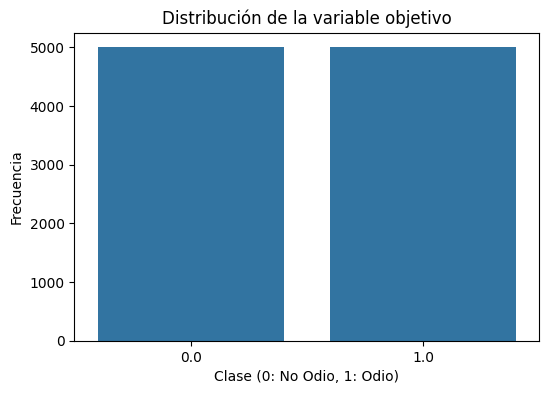

In [ ]:
print("\nDistribución de clases:")
print(df['label'].value_counts())
plt.figure(figsize=(6,4))
sns.countplot(x=df['label'])
plt.title('Distribución de la variable objetivo')
plt.xlabel('Clase (0: No Odio, 1: Odio)')
plt.ylabel('Frecuencia')
plt.show()

Vemos que la muestra está completamente balanceada.

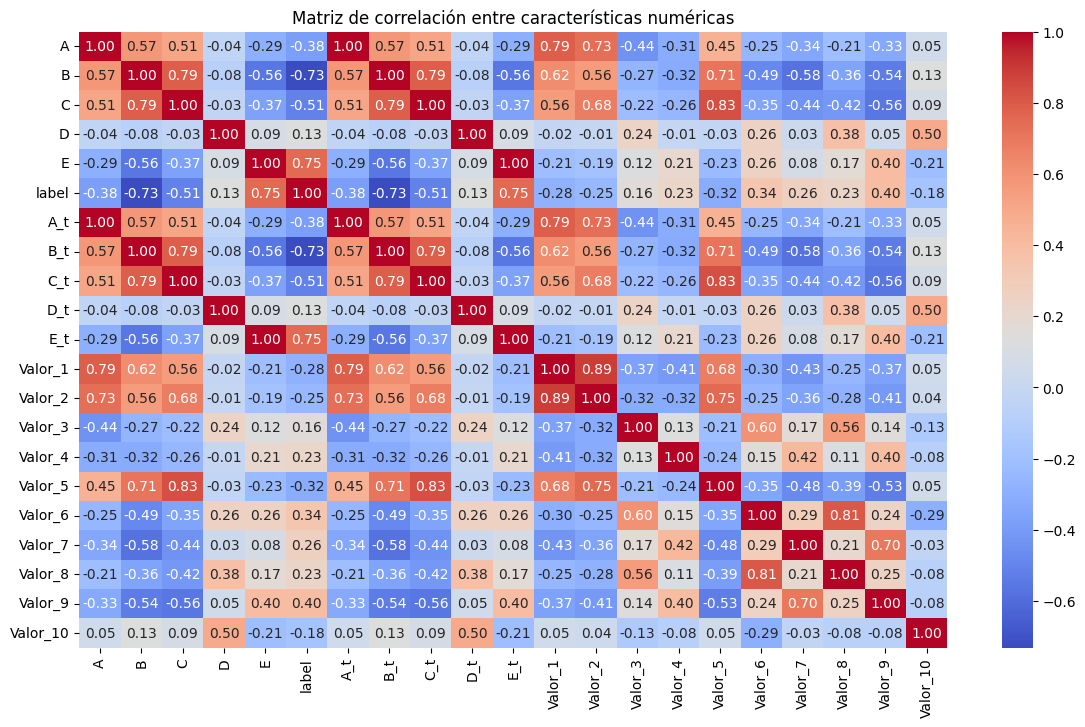

In [ ]:
plt.figure(figsize=(14,8))
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, fmt='.2f')
plt.title('Matriz de correlación entre características numéricas')
plt.show()

Vemos una correlación perfecta entre las variables (A, B, C, D y E) y su estandarización (como era de esperar).

In [ ]:
target_corr = corr_matrix['label'].abs().drop('label')
selected_features = target_corr[target_corr >= 0.70].index.tolist()
print(f"Características seleccionadas con correlación >= 0.70 con label: {selected_features}")

Características seleccionadas con correlación >= 0.70 con label: ['B', 'E', 'B_t', 'E_t']


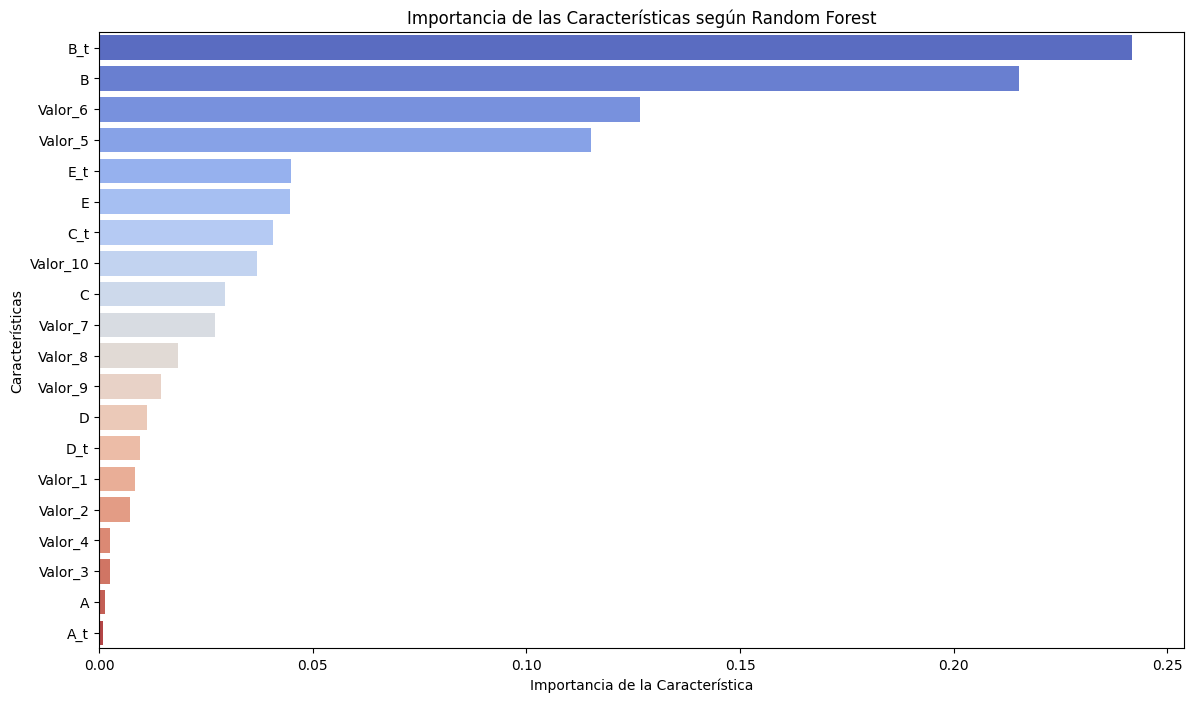

In [ ]:
X = df.drop(columns=['label', 'comentario'])
y = df['label']
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)
feature_importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(14, 8))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='coolwarm', hue=feature_importances.index, legend=False)
plt.xlabel('Importancia de la Característica')
plt.ylabel('Características')
plt.title('Importancia de las Características según Random Forest')
plt.show()

Entrenaremos y comprobaremos los modelos para cuatro situaciones:
- Teniendo en cuenta todas las características (a excepción de los comentarios lógicamente).
- Teniendo en cuenta las características con mayor correlación (sel).
- Teniendo en cuenta las variables estandarizadas (est).
- Teniendo en cuenta las variables estandarizadas combinadas (estcomb).
- Teniendo en cuenta las características con mayor importancia (featimp)

# Selección y entrenamiento de los modelos

In [ ]:
X_selected = df[selected_features]
X_est= df[['A', 'B', 'C', 'D', 'E']]
X_estcomb = df[['A_t', 'B_t', 'C_t', 'D_t', 'E_t']]
X_featimp = df[['B_t', 'B', 'Valor_6', 'Valor_5', 'E_t', 'E']]
X_train_all, X_test_all, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(X_selected, y, test_size=0.2, random_state=42)
X_train_est, X_test_est, y_train_est, y_test_est = train_test_split(X_est, y, test_size=0.2, random_state=42)
X_train_estcomb, X_test_estcomb, y_train_estcomb, y_test_estcomb = train_test_split(X_estcomb, y, test_size=0.2, random_state=42)
X_train_featimp, X_test_featimp, y_train_featimp, y_test_featimp = train_test_split(X_featimp, y, test_size=0.2, random_state=42)

## Random Forest

In [ ]:
param_grid_RF = {
    'n_estimators': [5, 10, 20, 50, 100],
    'max_depth': [10, 20, None]
}

rf = RandomForestClassifier()
grid_search_all_RF = GridSearchCV(rf, param_grid_RF, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_all_RF.fit(X_train_all, y_train)
grid_search_sel_RF = GridSearchCV(rf, param_grid_RF, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_sel_RF.fit(X_train_sel, y_train)
grid_search_est_RF = GridSearchCV(rf, param_grid_RF, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_est_RF.fit(X_train_est, y_train)
grid_search_estcomb_RF = GridSearchCV(rf, param_grid_RF, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_estcomb_RF.fit(X_train_estcomb, y_train)
grid_search_featimp_RF = GridSearchCV(rf, param_grid_RF, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_featimp_RF.fit(X_train_featimp, y_train)

best_model_all_RF = grid_search_all_RF.best_estimator_
print("Mejores hiperparámetros con todo el dataset:", grid_search_all_RF.best_params_)
best_model_sel_RF = grid_search_sel_RF.best_estimator_
print("Mejores hiperparámetros con caracteristicas seleccionadas:", grid_search_sel_RF.best_params_)
best_model_est_RF = grid_search_est_RF.best_estimator_
print("Mejores hiperparámetros con las cinco características estandarizadas:", grid_search_est_RF.best_params_)
best_model_estcomb_RF = grid_search_estcomb_RF.best_estimator_
print("Mejores hiperparámetros con las cinco características estandarizadas combinadas:", grid_search_estcomb_RF.best_params_)
best_model_featimp_RF = grid_search_featimp_RF.best_estimator_
print("Mejores hiperparámetros con las cinco características más importantes:", grid_search_featimp_RF.best_params_)

Mejores hiperparámetros con todo el dataset: {'max_depth': 10, 'n_estimators': 100}
Mejores hiperparámetros con caracteristicas seleccionadas: {'max_depth': None, 'n_estimators': 5}
Mejores hiperparámetros con las cinco características estandarizadas: {'max_depth': 10, 'n_estimators': 50}
Mejores hiperparámetros con las cinco características estandarizadas combinadas: {'max_depth': 10, 'n_estimators': 20}
Mejores hiperparámetros con las cinco características más importantes: {'max_depth': 10, 'n_estimators': 20}


## SVM

- En primer lugar, vamos a ver que parámetros vamos a utilizar para el modelo (para las diferentes alternativas).
- En segundo lugar, entrenaremos los modelos.
- En tercer lugar, evaluaremos el modelo para los datos de entrenamiento (esto ya es parte del apartado 3).
- En cuarto lugar, visualizaremos esos datos. Con esto seleccionaremos con uno de los modelos entrenados (el mejor).
- En quinto lugar comprobaremos el modelo para los datos de test.

In [ ]:
svm_model = SVC()
param_grid_SVM = {
    'C' : [0.1, 1, 10, 100, 1000],
    'kernel' : ['rbf'],
    'gamma' : ['scale']
}


# Aplicar Grid Search con validación cruzada de 5 folds
grid_search_all_SVM = GridSearchCV(svm_model, param_grid_SVM, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_all_SVM.fit(X_train_all, y_train)

grid_search_sel_SVM = GridSearchCV(svm_model, param_grid_SVM, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_sel_SVM.fit(X_train_sel, y_train_sel)

grid_search_est_SVM = GridSearchCV(svm_model, param_grid_SVM, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_est_SVM.fit(X_train_est, y_train_est)

grid_search_estcomb_SVM = GridSearchCV(svm_model, param_grid_SVM, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_estcomb_SVM.fit(X_train_estcomb, y_train_estcomb)

grid_search_featimp_SVM = GridSearchCV(svm_model, param_grid_SVM, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_featimp_SVM.fit(X_train_featimp, y_train_estcomb)

best_model_all_SVM = grid_search_all_SVM.best_estimator_
print("Mejores hiperparámetros con todo el dataset:", best_model_all_SVM )
best_model_sel_SVM = grid_search_sel_SVM.best_estimator_
print("Mejores hiperparámetros con caracteristicas seleccionadas:", best_model_sel_SVM)
best_model_est_SVM = grid_search_est_SVM.best_estimator_
print("Mejores hiperparámetros con las cinco características estandarizadas:", best_model_est_SVM)
best_model_estcomb_SVM = grid_search_estcomb_SVM.best_estimator_
print("Mejores hiperparámetros con las cinco características estandarizadas combinadas:", best_model_estcomb_SVM)
best_model_featimp_SVM = grid_search_featimp_SVM.best_estimator_
print("Mejores hiperparámetros con las cinco características más importantes:", best_model_featimp_SVM)

Mejores hiperparámetros con todo el dataset: SVC(C=1000)
Mejores hiperparámetros con caracteristicas seleccionadas: SVC(C=10)
Mejores hiperparámetros con las cinco características estandarizadas: SVC(C=100)
Mejores hiperparámetros con las cinco características estandarizadas combinadas: SVC(C=1000)
Mejores hiperparámetros con las cinco características más importantes: SVC(C=1000)


## Decision Tree

In [ ]:
param_grid_DT = {
    'max_depth': [10, 20, None]
}

dt = DecisionTreeClassifier()
grid_search_all_DT = GridSearchCV(dt, param_grid_DT, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_all_DT.fit(X_train_all, y_train)
grid_search_sel_DF = GridSearchCV(dt, param_grid_DT, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_sel_DF.fit(X_train_sel, y_train)
grid_search_est_DF = GridSearchCV(dt, param_grid_DT, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_est_DF.fit(X_train_est, y_train)
grid_search_estcomb_DF = GridSearchCV(dt, param_grid_DT, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_estcomb_DF.fit(X_train_estcomb, y_train)
grid_search_featimp_DF = GridSearchCV(dt, param_grid_DT, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_featimp_DF.fit(X_train_featimp, y_train)

best_model_all_DT = grid_search_all_DT.best_estimator_
print("Mejores hiperparámetros con todo el dataset:", grid_search_all_DT.best_params_)
best_model_sel_DT = grid_search_sel_DF.best_estimator_
print("Mejores hiperparámetros con caracteristicas seleccionadas:", grid_search_sel_DF.best_params_)
best_model_est_DT = grid_search_est_DF.best_estimator_
print("Mejores hiperparámetros con las cinco características estandarizadas:", grid_search_est_DF.best_params_)
best_model_estcomb_DT = grid_search_estcomb_DF.best_estimator_
print("Mejores hiperparámetros con las cinco características estandarizadas combinadas:", grid_search_estcomb_DF.best_params_)
best_model_featimp_DT = grid_search_featimp_DF.best_estimator_
print("Mejores hiperparámetros con las cinco características más importantes:", grid_search_featimp_DF.best_params_)

Mejores hiperparámetros con todo el dataset: {'max_depth': None}
Mejores hiperparámetros con caracteristicas seleccionadas: {'max_depth': 10}
Mejores hiperparámetros con las cinco características estandarizadas: {'max_depth': 10}
Mejores hiperparámetros con las cinco características estandarizadas combinadas: {'max_depth': 10}
Mejores hiperparámetros con las cinco características más importantes: {'max_depth': 10}


# Evaluación de los modelos y comparativa

- Después del entrenamiento de los diferentes modelos, se van en primer lugar a evaluar por separado (ya que tenemos diferentes opciones para cada uno de ellos) para los datos de entrenamiento.
- Se comprobarán los modelos para los datos de test y se seleccionará el mejor modelo de cada tipo.
- Finalmente, se compararán los tres y se concluirá con la decisión final.

Para la evaluación de los modelos, se tendrá en cuenta la precisión, el recall y el f1-score de los modelos. Además, se representarán mediante matrices de confusión.

# Evaluación conjunta y selección final

In [ ]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    return accuracy, precision, recall, f1

results = {}
best_models_all_names = ['All RF', 'All SVM', 'All DT']
best_models_all = [best_model_all_RF, best_model_all_SVM, best_model_all_DT]
best_models_selected_names = ['Selected RF', 'Selected SVM', 'Selected DT']
best_models_selected = [best_model_sel_RF, best_model_sel_SVM, best_model_sel_DT]
best_models_standarized_names = ['Standarized RF', 'Standarized SVM', 'Standarized DT']
best_models_standarized = [best_model_est_RF, best_model_est_SVM, best_model_est_DT]
best_models_standarized_combined_names = ['Std Combined RF', 'Std Combined SVM', 'Std Combined DT']
best_models_standarized_combined = [best_model_estcomb_RF, best_model_estcomb_SVM, best_model_estcomb_DT]
best_models_featimp_names = ['Feat Importance RF', 'Feat Importance SVM', 'Feat Importance DT']
best_models_featimp = [best_model_featimp_RF, best_model_featimp_SVM, best_model_featimp_DT]

for model_name, model in zip(best_models_all_names, best_models_all):
  results[model_name] = evaluate_model(model, X_test_all, y_test)
for model_name, model in zip(best_models_selected_names, best_models_selected):
  results[model_name] = evaluate_model(model, X_test_sel, y_test_sel)
for model_name, model in zip(best_models_standarized_names, best_models_standarized):
  results[model_name] = evaluate_model(model, X_test_est, y_test_est)
for model_name, model in zip(best_models_standarized_combined_names, best_models_standarized_combined):
  results[model_name] = evaluate_model(model, X_test_estcomb, y_test_estcomb)
for model_name, model in zip(best_models_featimp_names, best_models_featimp):
  results[model_name] = evaluate_model(model, X_test_featimp, y_test_featimp)
df_results = pd.DataFrame(results, index=["Accuracy", "Precision", "Recall", "F1-score"]).T
print(tabulate(df_results, headers="keys", tablefmt="grid", floatfmt=".6f", stralign="center", numalign="center"))

+---------------------+------------+-------------+----------+------------+
|                     |  Accuracy  |  Precision  |  Recall  |  F1-score  |
+=====================+============+=============+==========+============+
|       All RF        |  0.981500  |  0.976931   | 0.985830 |  0.981360  |
+---------------------+------------+-------------+----------+------------+
|       All SVM       |  0.977500  |  0.965449   | 0.989879 |  0.977511  |
+---------------------+------------+-------------+----------+------------+
|       All DT        |  0.977000  |  0.976721   | 0.976721 |  0.976721  |
+---------------------+------------+-------------+----------+------------+
|     Selected RF     |  0.972500  |  0.960513   | 0.984818 |  0.972514  |
+---------------------+------------+-------------+----------+------------+
|    Selected SVM     |  0.969500  |  0.950437   | 0.989879 |  0.969757  |
+---------------------+------------+-------------+----------+------------+
|     Selected DT     |  

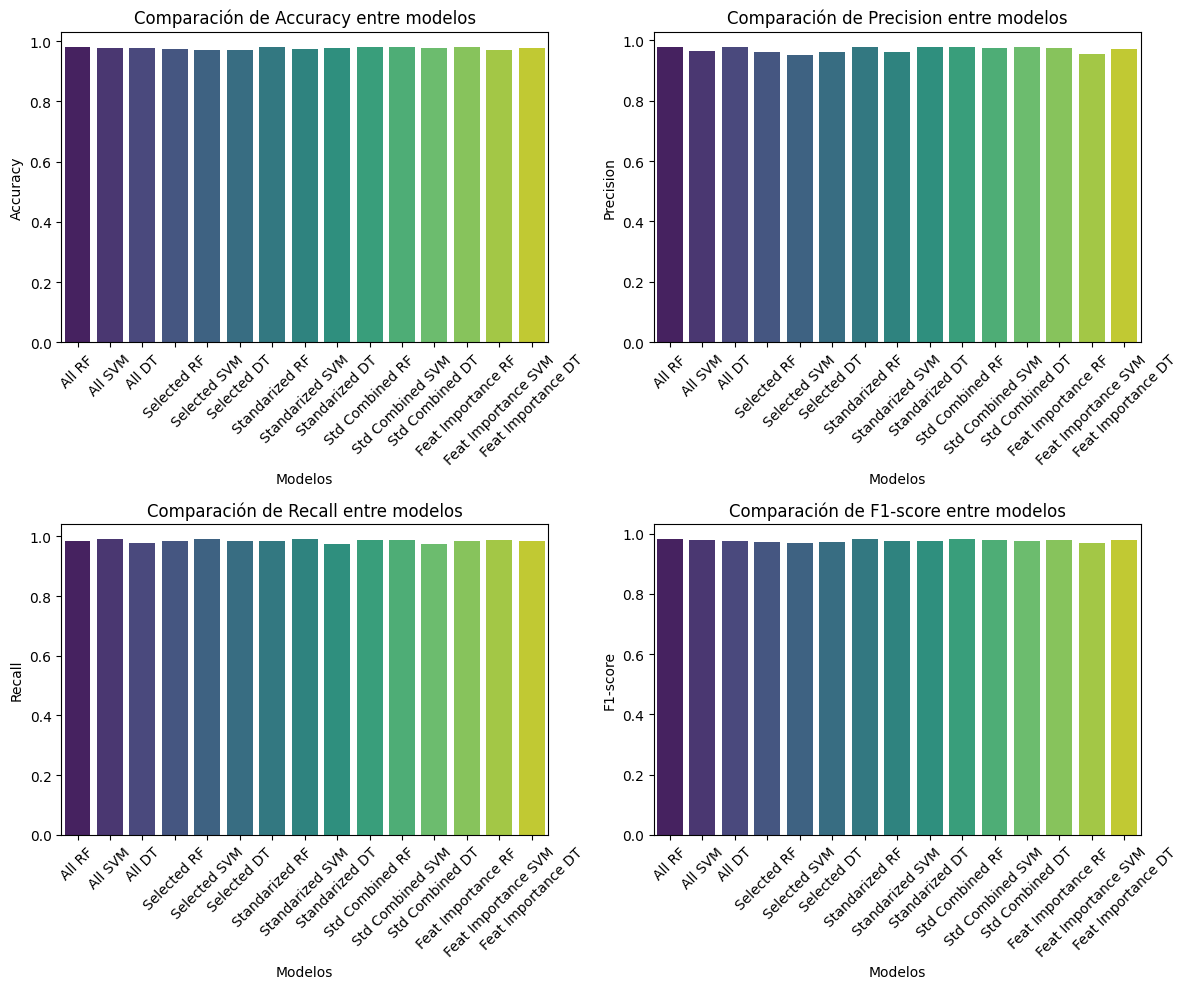

In [ ]:
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()
for i, metric in enumerate(metrics):
    sns.barplot(x=df_results.index, y=df_results[metric], palette='viridis', ax=axes[i], hue=df_results.index, legend=False)
    axes[i].set_title(f"Comparación de {metric} entre modelos")
    axes[i].set_ylabel(metric)
    axes[i].set_xlabel("Modelos")
    axes[i].set_xticks(range(len(df_results.index)))
    axes[i].set_xticklabels(df_results.index, rotation=45)

plt.tight_layout()
plt.show()

Como puede observarse gracias a las gráficas y la tabla de métricas en términos generales todos los modelos tienen un desempeño especialmente bueno

# Cálculo de las matrices de confusión

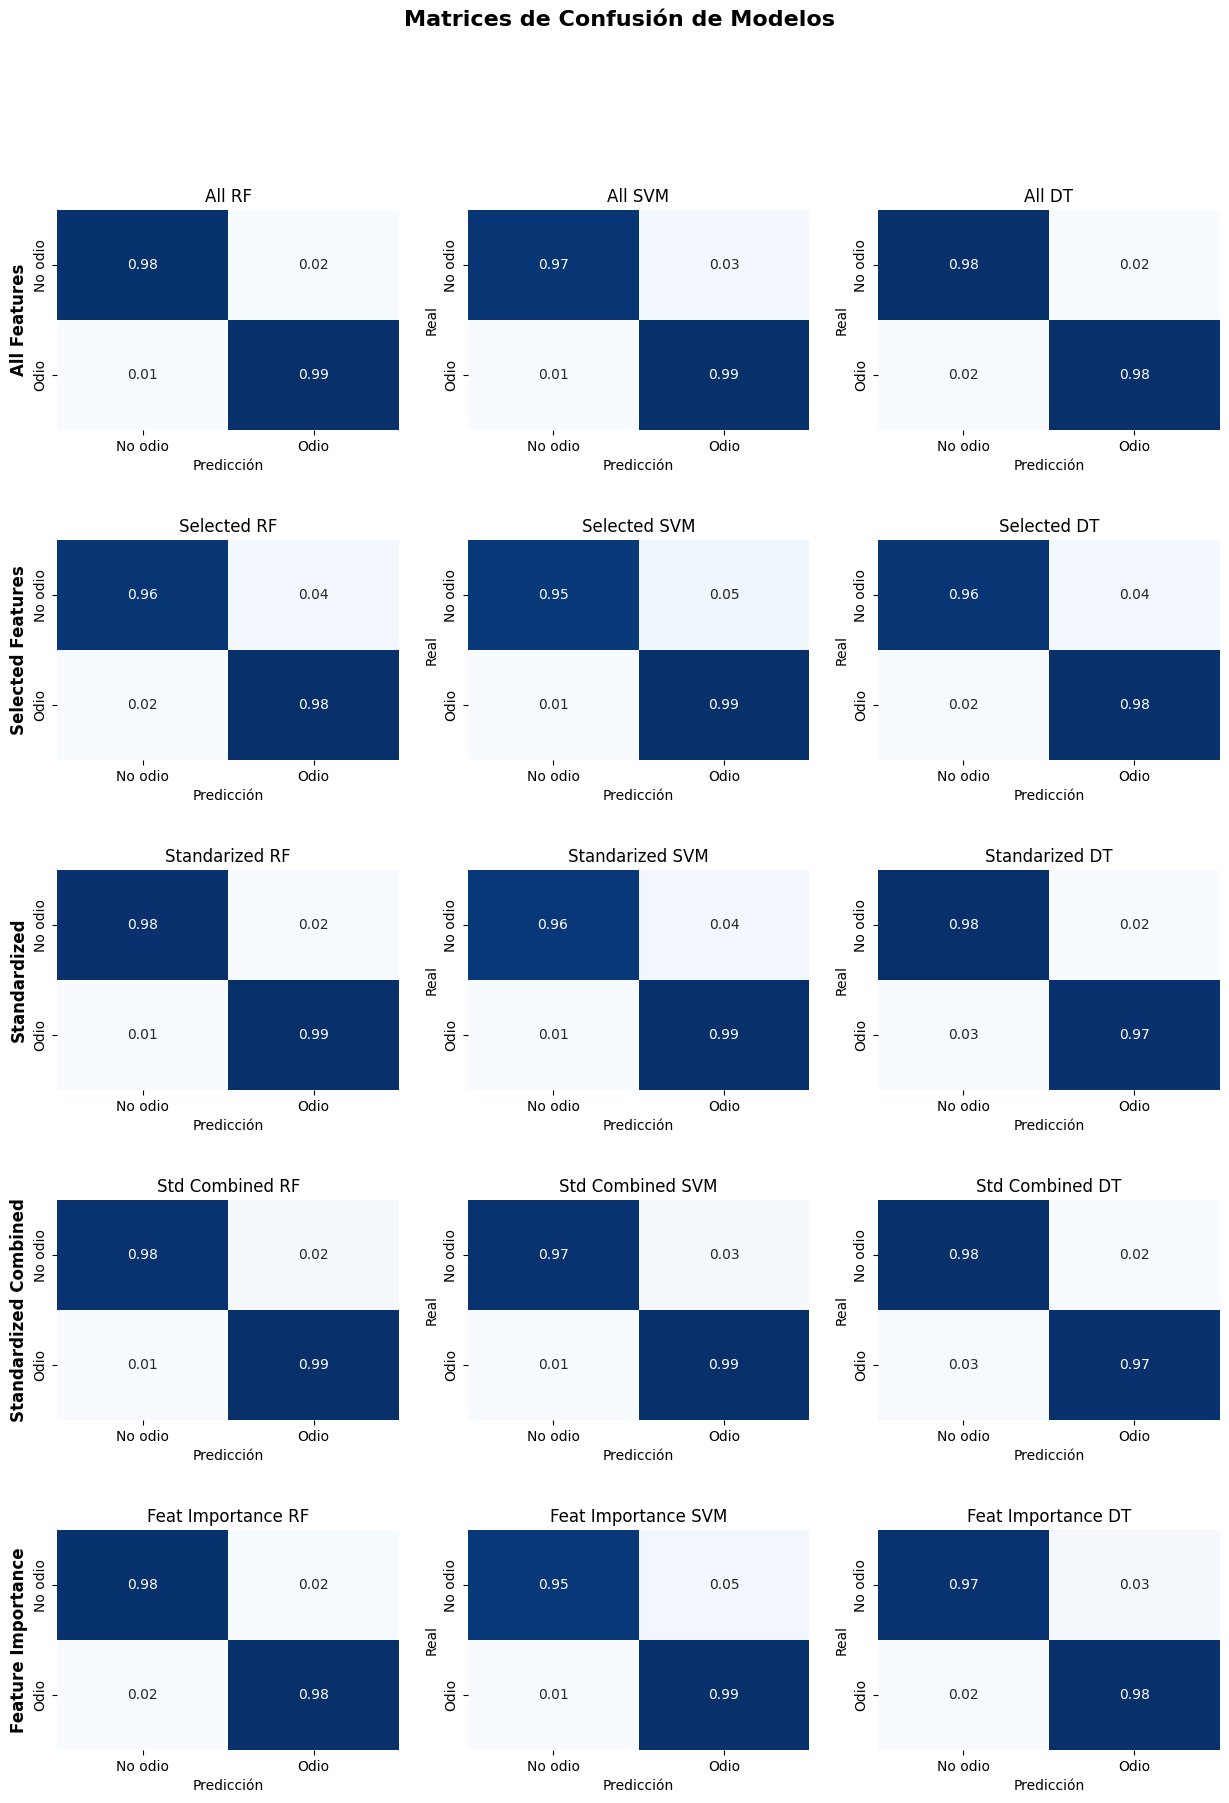

In [ ]:
model_groups = [
    (best_models_all, best_models_all_names, "All Features"),
    (best_models_selected, best_models_selected_names, "Selected Features"),
    (best_models_standarized, best_models_standarized_names, "Standardized"),
    (best_models_standarized_combined, best_models_standarized_combined_names, "Standardized Combined"),
    (best_models_featimp, best_models_featimp_names, "Feature Importance"),
]

fig, axes = plt.subplots(len(model_groups), len(best_models_all), figsize=(15, 20))
plt.subplots_adjust(hspace=0.5)
Clases = ["No odio", "Odio"]

for i, (models, names, title) in enumerate(model_groups):
    for j, (model, name) in enumerate(zip(models, names)):
        if "All" in name:
          X_test = X_test_all
          y_test = y_test
        elif "Selected" in name:
          X_test = X_test_sel
          y_test = y_test_sel
        elif "Standarized" in name:
          X_test = X_test_est
          y_test = y_test_est
        elif "Std Combined" in name:
          X_test = X_test_estcomb
          y_test = y_test_estcomb
        elif "Feat Importance" in name:
          X_test = X_test_featimp
          y_test = y_test_featimp
        y_pred = model.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)
        cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        ax = axes[i, j]
        sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", ax=ax, cbar=False,
            xticklabels=[Clases[i] for i in range(0, len(Clases))],
            yticklabels=[Clases[i] for i in range(0, len(Clases))])
        ax.set_title(f"{name}")
        ax.set_xlabel("Predicción")
        ax.set_ylabel("Real")
    axes[i, 0].set_ylabel(title, fontsize=12, fontweight='bold')

plt.suptitle("Matrices de Confusión de Modelos", fontsize=16, fontweight='bold')
plt.show()

In [ ]:
best_models_per_metric = df_results.idxmax(axis=0).to_frame(name="Best Model")
best_models_per_metric["Best Score"] = df_results.max(axis=0)
print(tabulate(best_models_per_metric, headers="keys", tablefmt="grid", floatfmt=".6f", stralign="center", numalign="center"))

+-----------+-----------------+--------------+
|           |   Best Model    |  Best Score  |
+===========+=================+==============+
| Accuracy  | Standarized RF  |   0.982000   |
+-----------+-----------------+--------------+
| Precision | Std Combined DT |   0.978659   |
+-----------+-----------------+--------------+
|  Recall   | Standarized SVM |   0.990891   |
+-----------+-----------------+--------------+
| F1-score  | Std Combined RF |   0.981891   |
+-----------+-----------------+--------------+


In [ ]:
print(tabulate(df_results.loc[['Std Combined RF']], headers="keys", tablefmt="grid", floatfmt=".6f", stralign="center", numalign="center"))

+-----------------+------------+-------------+----------+------------+
|                 |  Accuracy  |  Precision  |  Recall  |  F1-score  |
+=================+============+=============+==========+============+
| Std Combined RF |  0.982000  |  0.976000   | 0.987854 |  0.981891  |
+-----------------+------------+-------------+----------+------------+


Tras realizar una evaluación comparativa exhaustiva entre todos los modelos entrenados, con las diferentes variables disponibles. Se ha llegado a la conclusión de que la mejor configuración posible es hacer uso de un modelo de tipo Random Forest y utilizando las variables estandarizadas combinadas ya que son estas las que dan un mayor rendimiento. Para respaldar esta decisión se han añadido las tablas con los modelos que han obtenido un mayor valor para cada métrica. Y gracias a esto se observa que el modelo que hemos seleccionado es adecuado ya que tiene el mayor valor en las métricas de Accuracy y F1-score y tanto en Precision como en Recall su diferencia con los mejores modelos es menor a un 0.01.